In [1]:
import numpy as np 
import pandas as pd 
import sys
import os

sys.path.append(os.path.abspath(".."))

from analysis.analyze_src.basic_data_inspection import DataTypeInspectorStrategy
from analysis.analyze_src.basic_data_inspection import DataInspector
from analysis.analyze_src.missing_values_analysis import SimpleMissingValuesAnalyzer

from analysis.analyze_src.univariate_analysis import NumericalUnivariateAnalysis
from analysis.analyze_src.univariate_analysis import UnivariateAnalyzer
from analysis.analyze_src.bivariate_analysis import BivariateAnalyzer, NumericalBivariateAnalysis, CategoricalBivariateAnalysis
from analysis.analyze_src.multivariate_analysis import SimpleMultivariateAnalyzer

In [3]:
data_path = '../extract_path/AmesHousing.csv'
df = pd.read_csv(data_path)
df[df['Overall Qual'] == 2]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
181,182,902207130,30,RM,68.0,9656,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Abnorml,12789
302,303,910203250,30,RM,58.0,8154,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,ConLw,Normal,82000
662,663,535383060,30,RL,90.0,5400,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,59000
708,709,902205010,30,RM,50.0,5925,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,45000
742,743,903231060,30,RM,51.0,6120,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,1,2009,ConLw,Normal,60000
780,781,905228050,20,RL,NaN,9000,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,63900
907,908,909175080,30,RL,60.0,8400,Pave,NaN,Reg,Bnk,...,0,NaN,NaN,NaN,0,1,2009,WD,Normal,60000
945,946,912251110,30,I (all),109.0,21780,Grvl,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2009,ConLD,Normal,57625
1302,1303,902205070,20,RM,62.0,7311,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2008,WD,Abnorml,46500
1321,1322,902402260,70,RM,60.0,11340,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,11,2008,ConLD,Normal,55000


just testing

In [5]:
features = ['SalePrice', 'Gr Liv Area']
df_trasnformed = df.copy()
print("sales before: -----------")
print(df_trasnformed['SalePrice'].head())

for col in features:
    df_trasnformed[col] = np.log1p(df_trasnformed[col])
    print("successfully applied")

print("sales after: -----------")
df_trasnformed['SalePrice'].head()

sales before: -----------
0    215000
1    105000
2    172000
3    244000
4    189900
Name: SalePrice, dtype: int64
successfully applied
successfully applied
sales after: -----------


0    12.278398
1    11.561725
2    12.055256
3    12.404928
4    12.154258
Name: SalePrice, dtype: float64

2026-09-02 11:29:52,326 - INFO - Detecting outliers...
2026-09-02 11:29:52,327 - INFO - Detecting outliers using z-score with threshold 3
2026-09-02 11:29:52,333 - INFO - Found Order                0
PID                  0
MS SubClass         61
Lot Frontage        22
Lot Area            29
Overall Qual         4
Overall Cond        58
Year Built           8
Year Remod/Add       0
Mas Vnr Area        63
BsmtFin SF 1        17
BsmtFin SF 2        92
Bsmt Unf SF         16
Total Bsmt SF       21
1st Flr SF          29
2nd Flr SF          10
Low Qual Fin SF     31
Gr Liv Area         13
Bsmt Full Bath       2
Bsmt Half Bath     175
Full Bath            4
Half Bath           25
Bedroom AbvGr       30
Kitchen AbvGr      134
TotRms AbvGrd       19
Fireplaces          13
Garage Yr Blt        9
Garage Cars          1
Garage Area         17
Wood Deck SF        42
Open Porch SF       52
Enclosed Porch      88
3Ssn Porch          36
Screen Porch       107
Pool Area           13
Misc Val          

visualization before: 


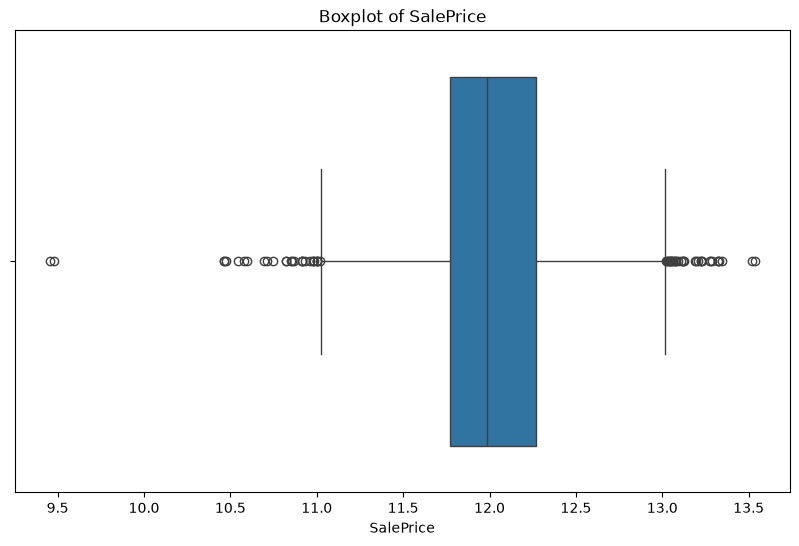

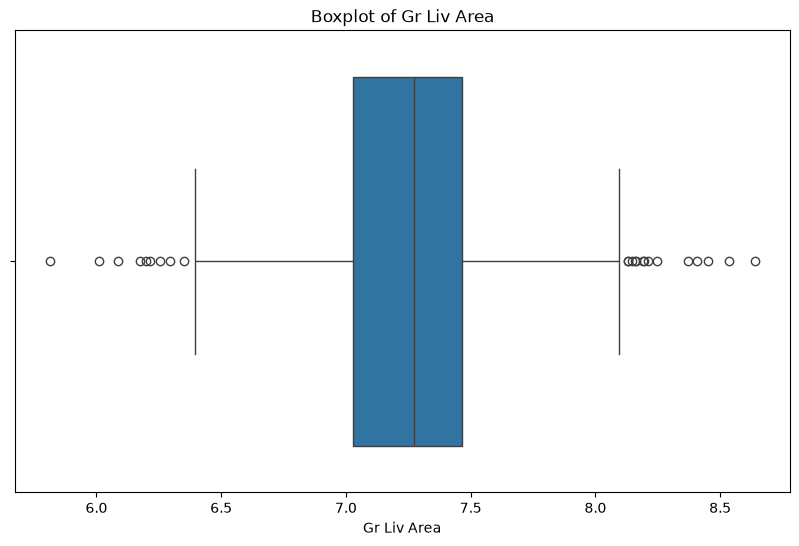

2026-09-02 11:29:52,485 - INFO - Outliers visualized successfully
2026-09-02 11:29:52,486 - INFO - Detecting outliers...
2026-09-02 11:29:52,486 - INFO - Detecting outliers using z-score with threshold 3
2026-09-02 11:29:52,491 - INFO - Found Order                0
PID                  0
MS SubClass         61
Lot Frontage        22
Lot Area            29
Overall Qual         4
Overall Cond        58
Year Built           8
Year Remod/Add       0
Mas Vnr Area        63
BsmtFin SF 1        17
BsmtFin SF 2        92
Bsmt Unf SF         16
Total Bsmt SF       21
1st Flr SF          29
2nd Flr SF          10
Low Qual Fin SF     31
Gr Liv Area         13
Bsmt Full Bath       2
Bsmt Half Bath     175
Full Bath            4
Half Bath           25
Bedroom AbvGr       30
Kitchen AbvGr      134
TotRms AbvGrd       19
Fireplaces          13
Garage Yr Blt        9
Garage Cars          1
Garage Area         17
Wood Deck SF        42
Open Porch SF       52
Enclosed Porch      88
3Ssn Porch          3

visualization after cleaning: 


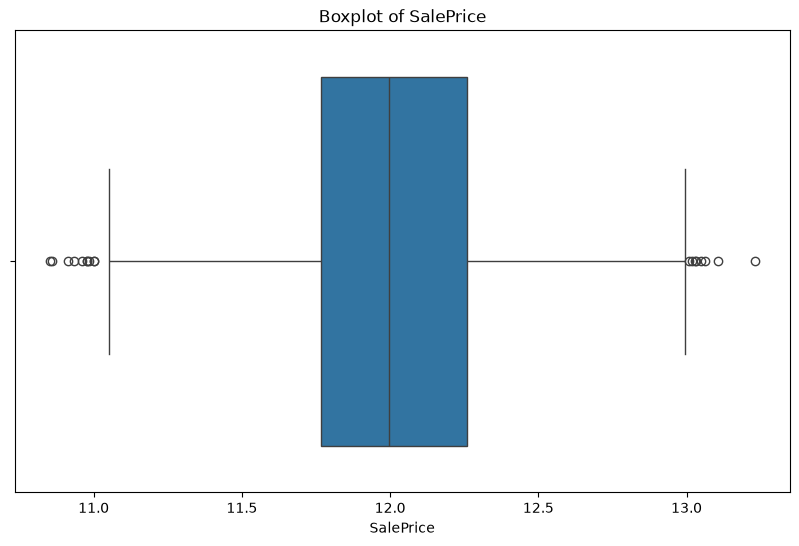

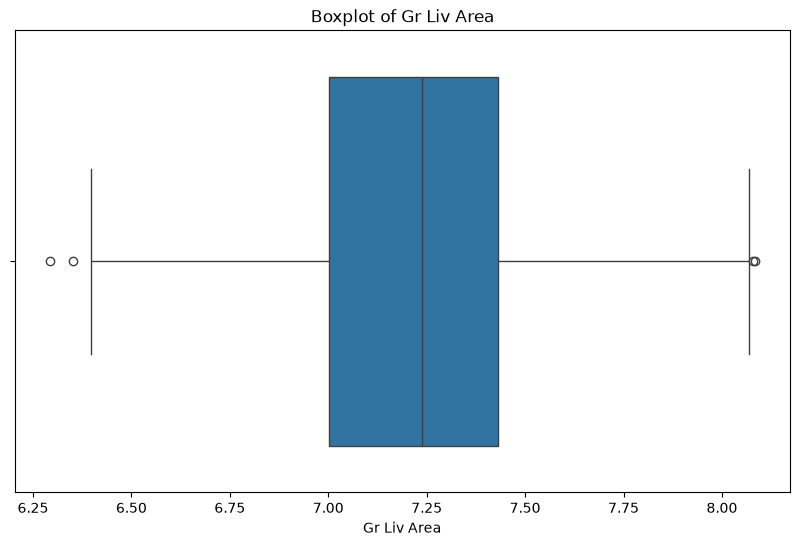

2026-09-02 11:29:52,629 - INFO - Outliers visualized successfully


In [8]:
from src.outlier_detection import ZScoreOutlierDetection
from src.outlier_detection import OutlierDetector

numeric_features = df_trasnformed.select_dtypes(include=[int, float])
outlier_strategy = OutlierDetector(ZScoreOutlierDetection(threshold=3))
outliers = outlier_strategy.detect_outliers(numeric_features)

print("visualization before: ")
outlier_strategy.visualize_outliers(numeric_features, features=features)

print("visualization after cleaning: ")
df_cleaned = outlier_strategy.handle_outliers(numeric_features, method="remove")
outlier_strategy.visualize_outliers(df_cleaned, features=features)


# print("outliers are :")
# outliers

In [3]:

data_inpector = DataInspector(DataTypeInspectorStrategy())
data_inpector.execute_strategy(df)


Data Types and Non-null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str  

In [4]:
from analysis.analyze_src.basic_data_inspection import SummaryStatisticsInspectionStrategy
data_inpector.set_strategy(SummaryStatisticsInspectionStrategy())

data_inpector.execute_strategy(df)


Summary Statistics (Numerical Features):
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026     


=== Identifying Missing Values ===
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

=== Visualizing Missing Values ===


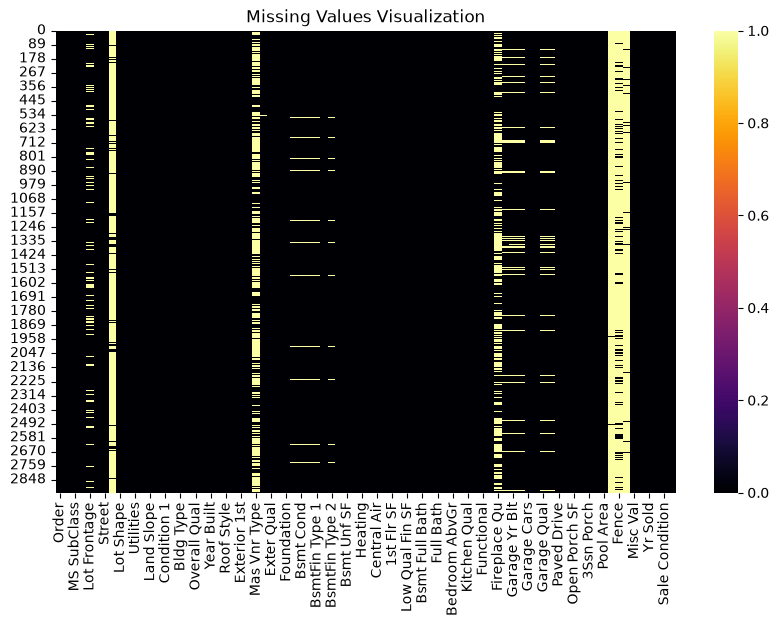

In [5]:
missing_values_analyser = SimpleMissingValuesAnalyzer()
missing_values_analyser.analyze(df)

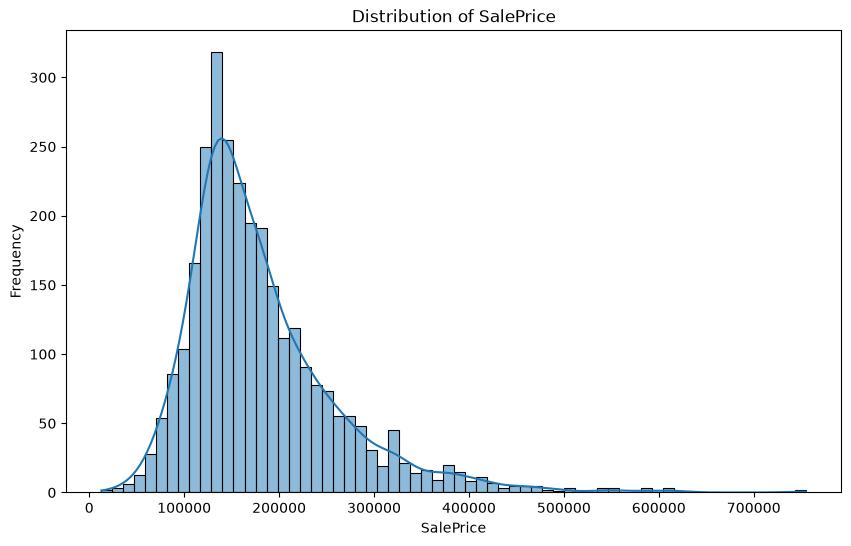

In [6]:
univariate_analyzer = UnivariateAnalyzer(NumericalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, "SalePrice")

/home/mouaad/Desktop/Projects/Learn/MLops/house_price_prediction/analysis/analyze_src/univariate_analysis.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


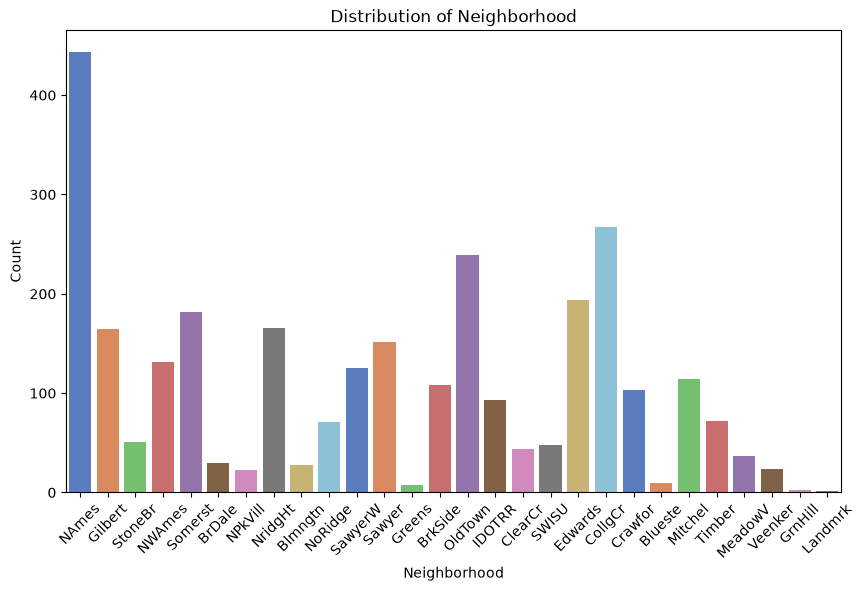

In [7]:
from analysis.analyze_src.univariate_analysis import CategoricalUnivariateAnalysis
univariate_analyzer.set_strategy(CategoricalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, "Neighborhood")

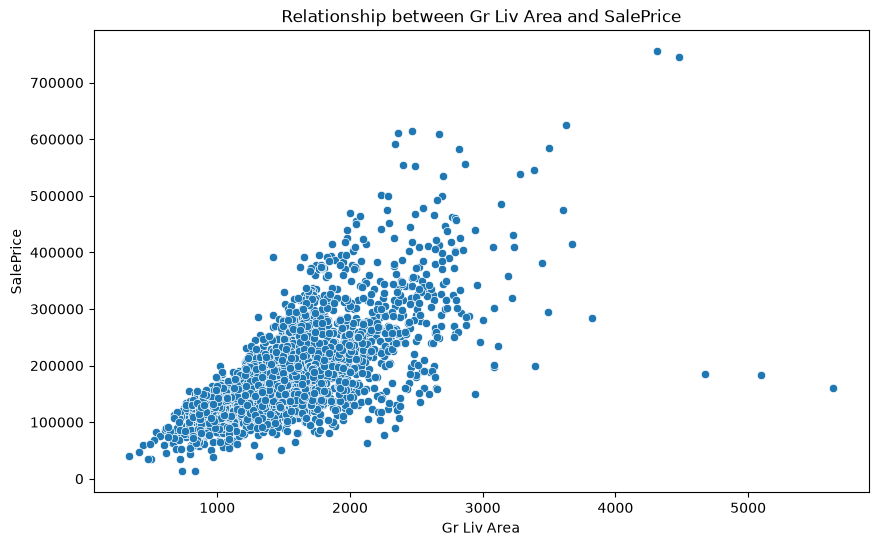

In [9]:
bivariate_analyzer = BivariateAnalyzer(NumericalBivariateAnalysis())
bivariate_analyzer.execute_analysis(df, 'Gr Liv Area', 'SalePrice')

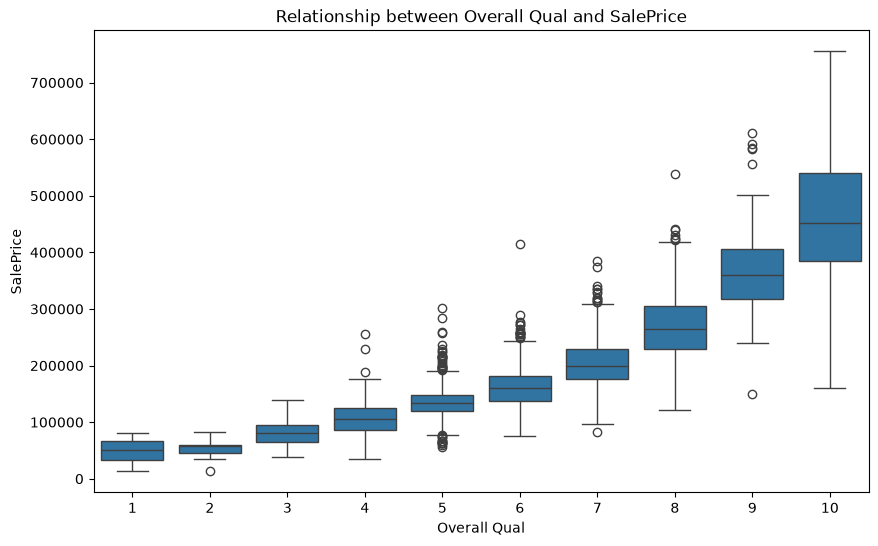

In [10]:
bivariate_analyzer.set_strategy(CategoricalBivariateAnalysis())
bivariate_analyzer.execute_analysis(df, 'Overall Qual', 'SalePrice')


 Generating Correlation Matrix


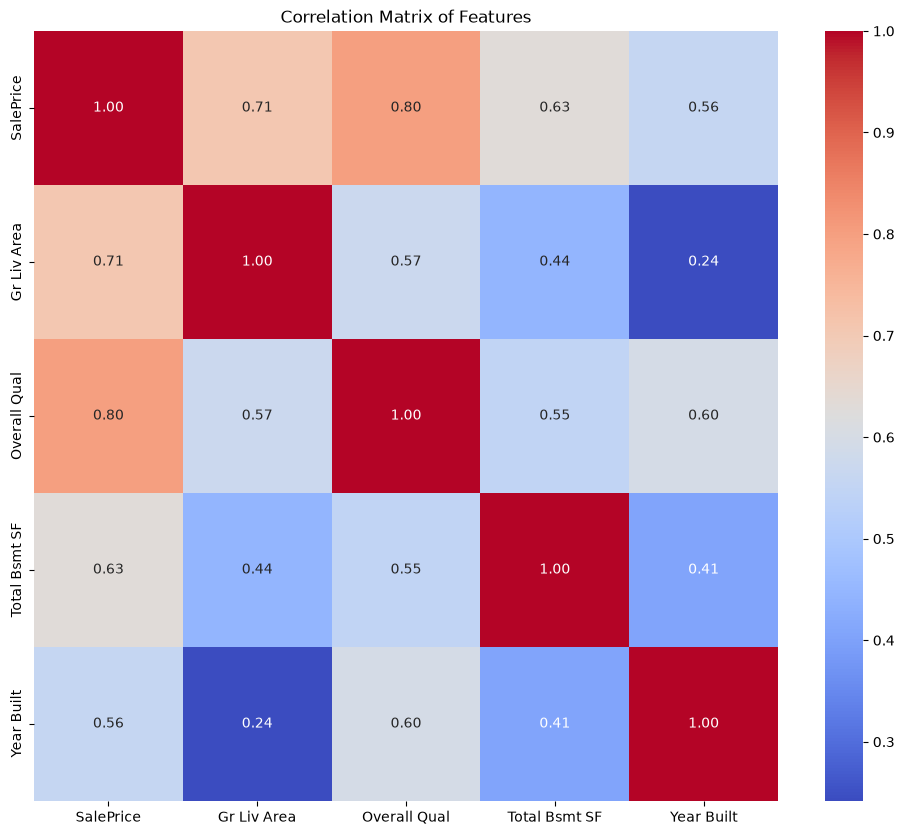

In [14]:
muli_variate_analysis = SimpleMultivariateAnalyzer()

selected_features = df[['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Total Bsmt SF', 'Year Built']]

muli_variate_analysis.generate_correlation_matrix(selected_features)


 Generating Pairplot


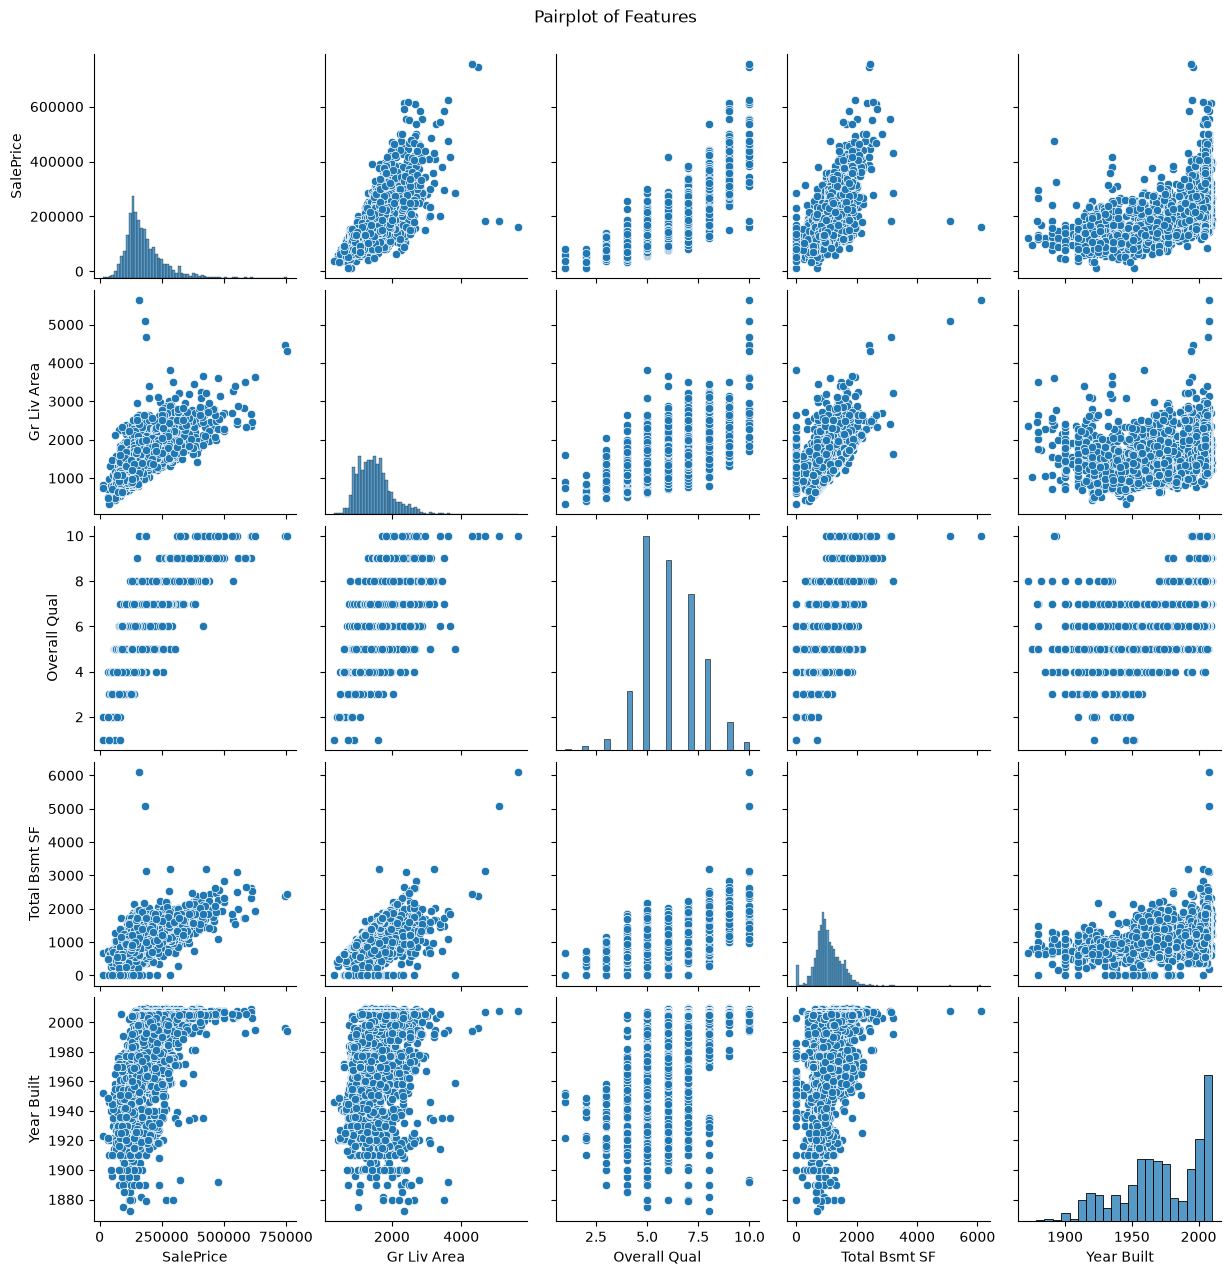

In [15]:
muli_variate_analysis.generate_pairplot(selected_features)